# Mahalanobis OOD Detection on Oxford-IIIT Pet

MobileNetV2 trained on Oxford-IIIT Pet. Per-layer Mahalanobis distance scoring against multiple out-of-domain sources, evaluated by AUROC, TNR@95% TPR and detection accuracy.


## 1. Configuration


In [1]:
import os, sys, time, json, random, urllib.request, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# ---- paths
DATA_DIR = "data"
CKPT_DIR = "checkpoints"
CACHE_DIR = "cache"
CKPT_PATH = os.path.join(CKPT_DIR, "mobilenetv2_oxford_best.pth")
for d in (DATA_DIR, CKPT_DIR, CACHE_DIR):
    os.makedirs(d, exist_ok=True)

# ---- training control
TRAIN_FROM_SCRATCH = False  # set True to force a retrain even if a checkpoint exists
EPOCHS = 8
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
SEED = 0

# ---- data + model
NUM_CLASSES = 37    # Oxford-IIIT Pet has 37 breed classes
IMG_SIZE = 224  # MobileNetV2's native ImageNet input size
NORM_MEAN = [0.485, 0.456, 0.406]   # standard ImageNet normalization (must match pretraining)
NORM_STD = [0.229, 0.224, 0.225]
LAYERS = list(range(19))    # All 19 blocks in MobileNetV2's `model.features` (stem + 17 inverted residuals + final 1x1)
LAYER_NAMES = [f"block{i}" for i in LAYERS]

# Per-layer spatial pool size before flatten. 1 = global average pool (collapse HxW to 1x1).
# Larger k preserves more spatial info, useful for early layers where channels are few.
POOL_SIZES = {f"block{i}": (4 if i <= 6 else 2 if i <= 13 else 1) for i in LAYERS}

# ---- OOD eval split sizes
# Held-out test size per side; follows Lee et al.'s split. Each OOD source caps at its own dataset size.
N_ID_VAL, N_ID_TEST = 1000, 5000
N_OOD_TEST = 5000

# ---- determinism
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = (torch.device("mps")  if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available()
          else torch.device("cpu"))
print("device:", DEVICE)
print("checkpoint exists:", os.path.exists(CKPT_PATH))

device: cuda
checkpoint exists: False


## 2. In-Domain (Oxford-IIIT Pet)

Full pipeline for the in-distribution data: dataset, transforms, model, training, evaluation, feature extraction, and Gaussian fit.

### Data

Downloads Oxford-IIIT Pet into `./data/`.


In [2]:
print("--> Oxford trainval"); OxfordIIITPet(root=DATA_DIR, split="trainval", target_types="category", download=True)
print("--> Oxford test");     OxfordIIITPet(root=DATA_DIR, split="test",     target_types="category", download=True)
print("data ready")

--> Oxford trainval
--> Oxford test
data ready


### Transforms

Mild augmentation for training, deterministic transform for eval.


In [3]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05),
                            scale=(0.9, 1.1), shear=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

### Model

MobileNetV2 with the final linear replaced by a 43-way head. The backbone is initialized from ImageNet-pretrained weights.

In [4]:
def build_model(pretrained=True, num_classes=NUM_CLASSES):
    weights = MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
    m = mobilenet_v2(weights=weights)
    m.classifier[1] = nn.Linear(1280, num_classes)
    return m

### Training

Skipped if `TRAIN_FROM_SCRATCH=False` and a checkpoint exists. Stratified 90/10 split, AdamW + cosine LR, 8 epochs, batch 64, save best by val accuracy. Per-epoch history is stored inside the checkpoint.


In [5]:
def train_model():
    full_train_aug = OxfordIIITPet(root=DATA_DIR, split="trainval", target_types="category", transform=train_tf, download=False)
    full_train_eval = OxfordIIITPet(root=DATA_DIR, split="trainval", target_types="category", transform=eval_tf,  download=False)
    labels = np.array([lbl for _, lbl in full_train_aug])
    rng = np.random.default_rng(SEED)
    train_idx, val_idx = [], []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]; rng.shuffle(idx)
        n_val = max(1, int(round(0.1 * len(idx))))
        val_idx.extend(idx[:n_val].tolist()); train_idx.extend(idx[n_val:].tolist())
    train_idx = np.array(train_idx); val_idx = np.array(val_idx)
    print(f"train={len(train_idx)}  val={len(val_idx)}  classes={len(np.unique(labels))}",
          flush=True)

    train_ds = Subset(full_train_aug,  train_idx)
    val_ds = Subset(full_train_eval, val_idx)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = build_model(pretrained=True).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    @torch.no_grad()
    def evaluate(loader):
        model.eval()
        correct = total = 0; loss_sum = 0.0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        return correct / total, loss_sum / total

    history, best_val = [], 0.0
    for epoch in range(EPOCHS):
        model.train()
        t0 = time.time()
        running_loss = running_correct = running_total = 0
        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x); loss = criterion(out, y)
            loss.backward(); optimizer.step()
            running_loss    += loss.item() * x.size(0)
            running_correct += (out.argmax(1) == y).sum().item()
            running_total   += y.size(0)
            if (i + 1) % 10 == 0 or i == 0:
                print(f"  ep{epoch+1} step {i+1}/{len(train_loader)} "
                      f"loss={running_loss/running_total:.4f} "
                      f"acc={running_correct/running_total:.4f}", flush=True)
        scheduler.step()
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        val_acc, val_loss = evaluate(val_loader)
        print(f"epoch {epoch+1}/{EPOCHS}  train_acc={train_acc:.4f}  "
              f"val_acc={val_acc:.4f}  val_loss={val_loss:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}  ({time.time()-t0:.1f}s)",
              flush=True)
        history.append({"epoch": epoch+1, "train_loss": train_loss,
                        "train_acc": train_acc, "val_loss": val_loss,
                        "val_acc": val_acc})
        if val_acc > best_val:
            best_val = val_acc
            torch.save({"model_state_dict": model.state_dict(),
                        "epoch": epoch+1, "val_acc": val_acc,
                        "best_val_acc": val_acc,
                        "train_idx": train_idx.tolist(),
                        "val_idx":   val_idx.tolist(),
                        "history": list(history)}, CKPT_PATH)
            print(f"  ↳ saved best ({val_acc:.4f}) to {CKPT_PATH}", flush=True)
    print(f"\nDONE  best_val_acc={best_val:.4f}")

if TRAIN_FROM_SCRATCH or not os.path.exists(CKPT_PATH):
    train_model()
else:
    print(f"checkpoint found at {CKPT_PATH} , skipping training")

train=3311  val=369  classes=37
  ep1 step 1/52 loss=3.6753 acc=0.0469
  ep1 step 10/52 loss=2.5671 acc=0.3484
  ep1 step 20/52 loss=1.9994 acc=0.4672
  ep1 step 30/52 loss=1.6980 acc=0.5318
  ep1 step 40/52 loss=1.4801 acc=0.5809
  ep1 step 50/52 loss=1.3689 acc=0.6103
epoch 1/8  train_acc=0.6158  val_acc=0.7344  val_loss=0.8635  lr=9.62e-04  (75.7s)
  ↳ saved best (0.7344) to checkpoints\mobilenetv2_oxford_best.pth
  ep2 step 1/52 loss=0.5311 acc=0.8906
  ep2 step 10/52 loss=0.6172 acc=0.8219
  ep2 step 20/52 loss=0.5715 acc=0.8367
  ep2 step 30/52 loss=0.5870 acc=0.8219
  ep2 step 40/52 loss=0.5990 acc=0.8141
  ep2 step 50/52 loss=0.6164 acc=0.8059
epoch 2/8  train_acc=0.8043  val_acc=0.7263  val_loss=0.8685  lr=8.54e-04  (97.6s)
  ep3 step 1/52 loss=0.4615 acc=0.8438
  ep3 step 10/52 loss=0.4331 acc=0.8688
  ep3 step 20/52 loss=0.4030 acc=0.8766
  ep3 step 30/52 loss=0.3854 acc=0.8812
  ep3 step 40/52 loss=0.3771 acc=0.8816
  ep3 step 50/52 loss=0.3839 acc=0.8784
epoch 3/8  train_a

### Loaded model


In [6]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
model = build_model(pretrained=False)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(DEVICE).eval()

train_idx = np.asarray(ckpt["train_idx"])
val_idx = np.asarray(ckpt["val_idx"])
print(f"loaded checkpoint  epoch={ckpt['epoch']}  best_val_acc={ckpt['val_acc']:.4f}")
print(f"split sizes: train={len(train_idx)}  val={len(val_idx)}")

loaded checkpoint  epoch=8  best_val_acc=0.9024
split sizes: train=3311  val=369


### Training curves

Train and val loss/accuracy per epoch from the checkpoint history.


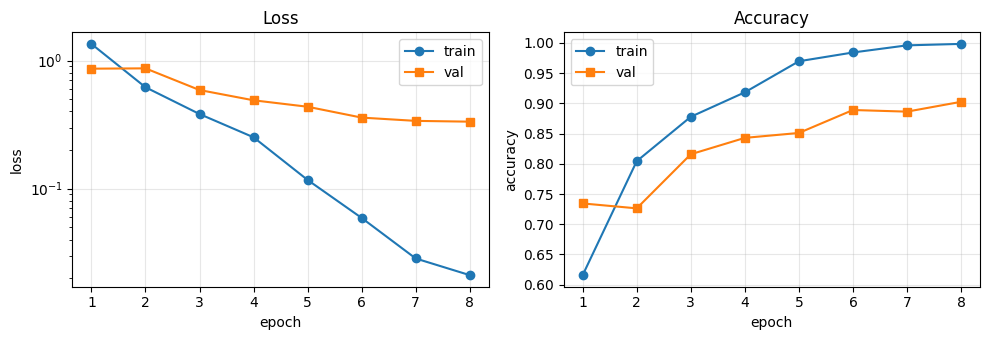

In [7]:
hist = ckpt.get("history")
if hist:
    epochs = [h["epoch"] for h in hist]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
    ax1.plot(epochs, [h["train_loss"] for h in hist], "-o", label="train")
    ax1.plot(epochs, [h["val_loss"]   for h in hist], "-s", label="val")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.set_yscale("log")
    ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs, [h["train_acc"] for h in hist], "-o", label="train")
    ax2.plot(epochs, [h["val_acc"]   for h in hist], "-s", label="val")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
    ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("no history in checkpoint (older format)")

### Accuracy on held-out val and on the official test set


In [8]:
oxford_train_eval = OxfordIIITPet(root=DATA_DIR, split="trainval", target_types="category", transform=eval_tf)
oxford_test = OxfordIIITPet(root=DATA_DIR, split="test",     target_types="category", transform=eval_tf)

@torch.no_grad()
def accuracy(loader):
    correct = total = 0
    for x, y in loader:
        x = x.to(DEVICE)
        correct += (model(x).argmax(1).cpu() == y).sum().item()
        total += y.size(0)
    return correct / total

# Val acc was recorded during training and stored in the checkpoint, no recompute needed.
modelval_acc = ckpt["val_acc"]

# Cache test accuracy: deterministic, so we only ever compute it once.
test_acc_path = os.path.join(CACHE_DIR, "oxford_test_acc.json")
if os.path.exists(test_acc_path):
    test_acc = json.load(open(test_acc_path))["test_acc"]
else:
    test_acc = accuracy(DataLoader(oxford_test, batch_size=128, num_workers=0))
    with open(test_acc_path, "w") as f:
        json.dump({"test_acc": test_acc}, f)

print(f"Oxford-IIIT Pet model-val top-1 (random 10% of train, leaky): {modelval_acc:.4f}")
print(f"Oxford-IIIT Pet official test  top-1: {test_acc:.4f}")

Oxford-IIIT Pet model-val top-1 (random 10% of train, leaky): 0.9024
Oxford-IIIT Pet official test  top-1: 0.8525


### Feature extraction

Hook all 19 MobileNetV2 blocks, pool the spatial maps (per-layer pool size
from `POOL_SIZES`), cache to `./cache/`.


In [9]:
class FeatureHooks:
    """Attach forward hooks; collect pooled features (B,C) per named layer."""
    def __init__(self, model, layer_indices):
        self.layer_indices = layer_indices
        self.features = {}
        self._handles = []
        for idx in layer_indices:
            name = f"block{idx}"
            self._handles.append(model.features[idx].register_forward_hook(self._hook(name)))
    def _hook(self, name):
        def fn(_, __, out):
            if out.dim() == 4:
                k = POOL_SIZES.get(name, 1)
                if k <= 1:
                    out = out.mean(dim=(2, 3))                     # global avg pool
                else:
                    out = F.adaptive_avg_pool2d(out, k).flatten(1) # spatial-grid avg pool
            self.features[name] = out
        return fn
    def remove(self):
        for h in self._handles: h.remove()

hooks = FeatureHooks(model, LAYERS)

def loader(ds, batch=128):
    return DataLoader(ds, batch_size=batch, shuffle=False, num_workers=0)

@torch.no_grad()
def extract(ds, also_logits=False, labels_too=False):
    feats = {n: [] for n in LAYER_NAMES}
    logits, labels = [], []
    for batch in loader(ds):
        x, y = batch
        x = x.to(DEVICE)
        out = model(x)
        for n in LAYER_NAMES:
            feats[n].append(hooks.features[n].detach().cpu().numpy())
        if also_logits: logits.append(out.detach().cpu().numpy())
        if labels_too: labels.append(np.asarray(y))
    feats = {k: np.concatenate(v, 0) for k, v in feats.items()}
    out = {"features": feats}
    if also_logits: out["logits"] = np.concatenate(logits, 0)
    if labels_too:  out["labels"] = np.concatenate(labels, 0)
    return out

def extract_cached(name, ds, also_logits=False, labels_too=False):
    path = os.path.join(CACHE_DIR, f"{name}.npz")
    if os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        out = {"features": {k.replace("feat_", ""): d[k] for k in d.files if k.startswith("feat_")}}
        if "logits" in d.files: out["logits"] = d["logits"]
        if "labels" in d.files: out["labels"] = d["labels"]
        print(f"  load  {name}.npz")
        return out
    print(f"  extract {name} ({len(ds)} samples)", flush=True)
    t0 = time.time()
    out = extract(ds, also_logits=also_logits, labels_too=labels_too)
    save = {f"feat_{k}": v for k, v in out["features"].items()}
    if "logits" in out: save["logits"] = out["logits"]
    if "labels" in out: save["labels"] = out["labels"]
    np.savez_compressed(path, **save)
    print(f"  done in {time.time()-t0:.1f}s")
    return out

In [10]:
oxford_fit_ds = Subset(oxford_train_eval, train_idx)

rng = np.random.default_rng(1)
perm_id = rng.permutation(len(oxford_test))[:N_ID_VAL + N_ID_TEST]
id_test_ds = Subset(oxford_test, perm_id[N_ID_VAL:])

print("extracting features ...")
fit_out = extract_cached("fit",     oxford_fit_ds, labels_too=True)
id_test_out = extract_cached("id_test", id_test_ds,   also_logits=True, labels_too=True)

print("\nlayer dims:")
for n in LAYER_NAMES:
    print(f"  {n}: dim={fit_out['features'][n].shape[1]}  "
          f"N_fit={fit_out['features'][n].shape[0]}")

extracting features ...
  load  fit.npz
  load  id_test.npz

layer dims:
  block0: dim=512  N_fit=23976
  block1: dim=256  N_fit=23976
  block2: dim=384  N_fit=23976
  block3: dim=384  N_fit=23976
  block4: dim=512  N_fit=23976
  block5: dim=512  N_fit=23976
  block6: dim=512  N_fit=23976
  block7: dim=256  N_fit=23976
  block8: dim=256  N_fit=23976
  block9: dim=256  N_fit=23976
  block10: dim=256  N_fit=23976
  block11: dim=384  N_fit=23976
  block12: dim=384  N_fit=23976
  block13: dim=384  N_fit=23976
  block14: dim=160  N_fit=23976
  block15: dim=160  N_fit=23976
  block16: dim=160  N_fit=23976
  block17: dim=320  N_fit=23976
  block18: dim=1280  N_fit=23976


### Per-class Gaussians (tied covariance)

Per-class mean plus one shared covariance, matching Eq. 1 of the report.


In [11]:
def fit_gaussian(feats, labels, num_classes, shrink=0.1):
    """Per-class means and a single tied covariance (Eq. 1 of the report)
    with Ledoit-Wolf-style shrinkage for numerical conditioning at high-D layers."""
    feats = np.asarray(feats, dtype=np.float64)
    D = feats.shape[1]
    means = np.zeros((num_classes, D))
    centered = []
    for c in range(num_classes):
        m = feats[labels == c]
        if len(m) == 0: continue
        mu = m.mean(axis=0); means[c] = mu
        centered.append(m - mu)
    centered = np.concatenate(centered, axis=0)
    cov = (centered.T @ centered) / centered.shape[0]
    target = (np.trace(cov) / D) * np.eye(D)
    cov = (1 - shrink) * cov + shrink * target
    return means.astype(np.float32), np.linalg.inv(cov).astype(np.float32)

gaussians = {}
fit_labels = fit_out["labels"]
for n in LAYER_NAMES:
    means, prec = fit_gaussian(fit_out["features"][n], fit_labels, NUM_CLASSES)
    gaussians[n] = (means, prec)
    print(f"  {n}: means {means.shape}  precision {prec.shape}")

  block0: means (37, 512)  precision (512, 512)
  block1: means (37, 256)  precision (256, 256)
  block2: means (37, 384)  precision (384, 384)
  block3: means (37, 384)  precision (384, 384)
  block4: means (37, 512)  precision (512, 512)
  block5: means (37, 512)  precision (512, 512)
  block6: means (37, 512)  precision (512, 512)
  block7: means (37, 256)  precision (256, 256)
  block8: means (37, 256)  precision (256, 256)
  block9: means (37, 256)  precision (256, 256)
  block10: means (37, 256)  precision (256, 256)
  block11: means (37, 384)  precision (384, 384)
  block12: means (37, 384)  precision (384, 384)
  block13: means (37, 384)  precision (384, 384)
  block14: means (37, 160)  precision (160, 160)
  block15: means (37, 160)  precision (160, 160)
  block16: means (37, 160)  precision (160, 160)
  block17: means (37, 320)  precision (320, 320)
  block18: means (37, 1280)  precision (1280, 1280)


## 3. Out-of-Domain Analysis

All OOD evaluations below share the same machinery: per-layer Mahalanobis
scoring against the fitted Gaussians, the same ID test split, the same
metrics. Helpers are defined once in the next cell; every OOD source
calls `analyze_ood_source(...)`. Adding a new source is one cell.

Mahalanobis score:

$$
\text{score}(x) \;=\; \min_{c}\; \bigl(f(x) - \hat{\mu}_c\bigr)^{\!\top}\, \hat{\Sigma}^{-1}\, \bigl(f(x) - \hat{\mu}_c\bigr)
$$

Lower means more in-distribution. Same as Lee et al. Eq. 2 (and Eq. 2 in
the report), with the outer minus sign dropped.


In [12]:
# --- Shared scoring helpers (used for every OOD source below) ---

def mahalanobis_min(feats, means, precision):
    feats = np.asarray(feats, dtype=np.float64)
    means = np.asarray(means, dtype=np.float64)
    P = np.asarray(precision, dtype=np.float64)
    Px = feats @ P
    Pmu = means @ P
    quad_x = np.einsum("nd,nd->n", Px, feats)
    quad_mu = np.einsum("cd,cd->c", Pmu, means)
    cross = Px @ means.T
    return (quad_x[:, None] + quad_mu[None, :] - 2.0 * cross).min(axis=1)

def metric_set(scores_id, scores_ood, higher_is_more_id=True):
    s_id = -scores_id if higher_is_more_id else scores_id
    s_ood = -scores_ood if higher_is_more_id else scores_ood
    y = np.concatenate([np.zeros_like(s_id), np.ones_like(s_ood)])
    s = np.concatenate([s_id, s_ood])
    auroc = roc_auc_score(y, s)
    thr = np.quantile(s_id, 0.95)
    tnr95 = float((s_ood > thr).mean())
    grid = np.quantile(s, np.linspace(0, 1, 1001))
    best = 0.0
    for t in grid:
        best = max(best, 0.5 * ((s_ood >= t).mean() + (s_id < t).mean()))
    return {"auroc": float(auroc), "tnr@95": tnr95, "det_acc": float(best)}

def score_layer(n, feats):
    means, prec = gaussians[n]
    return mahalanobis_min(feats, means, prec)

class OODWrapper(Dataset):
    """Wrap any (image, label) dataset to return (image, 0). Optional subsampling."""
    def __init__(self, base, n=None, seed=0):
        if n is None or n >= len(base):
            self.idx = np.arange(len(base))
        else:
            rng = np.random.default_rng(seed)
            self.idx = rng.permutation(len(base))[:n]
        self.base = base
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        x, _ = self.base[int(self.idx[i])]
        return x, 0

def evaluate_ood_source(ood_ds, name):
    """Per-layer Mahalanobis metrics for any OOD dataset. Caches features under
    `cache/ood_test_{name}.npz`. Returns dict with per_layer, md_ood."""
    ood_out = extract_cached(f"ood_test_{name}", ood_ds, also_logits=True)
    md_ood = {n: score_layer(n, ood_out["features"][n]) for n in LAYER_NAMES}
    per_layer_metrics = {n: metric_set(md_id_test[n], md_ood[n], higher_is_more_id=False)
                         for n in LAYER_NAMES}
    return {"per_layer": per_layer_metrics, "md_ood": md_ood}

def _print_per_layer_table(result):
    pl = result["per_layer"]
    print(f"{'layer':10s}  {'AUROC':>7s}  {'TNR@95':>7s}  {'DetAcc':>7s}")
    for n in LAYER_NAMES:
        m = pl[n]
        print(f"{n:10s}  {m['auroc']:.4f}   {m['tnr@95']:.4f}   {m['det_acc']:.4f}")

def _plot_bar(result, display_name):
    pl = result["per_layer"]
    vals = [pl[n]["auroc"] for n in LAYER_NAMES]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.bar(LAYER_NAMES, vals, color="steelblue")
    ax.set_ylim(0.5, 1.005); ax.set_ylabel("AUROC")
    ax.set_title(f"Mahalanobis AUROC per block, OOD = {display_name}")
    ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, 0.51, f"{v:.3f}", ha="center", va="bottom",
                fontsize=8.5, rotation=90, color="white", fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

def _plot_roc(result, display_name):
    from sklearn.metrics import roc_curve
    colors = plt.cm.tab20(np.linspace(0, 1, len(LAYER_NAMES)))
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for n, color in zip(LAYER_NAMES, colors):
        sid = md_id_test[n]; sood = result["md_ood"][n]
        y = np.r_[np.zeros(len(sid)), np.ones(len(sood))]
        s = np.r_[sid, sood]                                  # higher distance = more OOD-like
        fpr, tpr, _ = roc_curve(y, s)
        ax.plot(fpr, tpr, color=color, lw=1.3, label=n)
    ax.plot([0, 1], [0, 1], "k--", lw=0.5)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC curves per block, OOD = {display_name}")
    ax.legend(loc="lower right", ncol=2, fontsize=7)
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_score_distribution(result, display_name, n_top=4):
    """Score-distribution histograms at the top n_top layers (sorted by AUROC desc)."""
    pl = result["per_layer"]
    top = sorted(LAYER_NAMES, key=lambda n: pl[n]["auroc"], reverse=True)[:n_top]
    ncols = 2
    nrows = (n_top + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.0 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, bl in zip(axes, top):
        sid = md_id_test[bl]; sood = result["md_ood"][bl]
        lo, hi = float(min(sid.min(), sood.min())), float(max(sid.max(), sood.max()))
        bins = np.linspace(lo, hi, 60)
        ax.hist(sid,  bins=bins, alpha=0.6, color="steelblue",  label=f"ID, n={len(sid)}")
        ax.hist(sood, bins=bins, alpha=0.6, color="darkorange", label=f"OOD, n={len(sood)}")
        ax.set_xlabel(f"Mahalanobis distance at {bl}")
        ax.set_ylabel("count")
        ax.set_title(f"{bl}  AUROC={pl[bl]['auroc']:.4f}")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    for ax in axes[len(top):]:
        ax.axis("off")
    fig.suptitle(f"Score distributions at top {n_top} layers, OOD = {display_name}")
    plt.tight_layout(); plt.show()

def analyze_ood_source(ood_ds, name, display_name=None):
    """End-to-end per-layer OOD analysis: scoring + table + bar + ROC + histogram.
    Returns the result dict (per_layer, md_ood)."""
    display_name = display_name or name
    result = evaluate_ood_source(ood_ds, name)
    _print_per_layer_table(result)
    _plot_bar(result, display_name)
    _plot_roc(result, display_name)
    _plot_score_distribution(result, display_name)
    return result

# Reference ID scores, computed once and reused by every OOD evaluation
md_id_test = {n: score_layer(n, id_test_out["features"][n]) for n in LAYER_NAMES}

### Tiny-ImageNet

Tiny-ImageNet raw images: 100000
Excluded wnids: ['n02085620', 'n02094433', 'n02099601', 'n02099712', 'n02106662', 'n02113799', 'n02123045', 'n02124075']
Excluded images: 4000
Tiny-ImageNet used for OOD: 5000 images
  load  ood_test_tiny_imagenet.npz
layer         AUROC   TNR@95   DetAcc
block0      0.9006   0.5206   0.8162
block1      0.9328   0.6482   0.8590
block2      0.9871   0.9642   0.9574
block3      0.9908   0.9800   0.9656
block4      0.9939   0.9852   0.9708
block5      0.9947   0.9880   0.9718
block6      0.9953   0.9882   0.9746
block7      0.9964   0.9952   0.9774
block8      0.9971   0.9958   0.9802
block9      0.9972   0.9960   0.9802
block10     0.9974   0.9958   0.9812
block11     0.9980   0.9958   0.9826
block12     0.9974   0.9922   0.9796
block13     0.9950   0.9848   0.9702
block14     0.9759   0.8326   0.9452
block15     0.9691   0.7398   0.9454
block16     0.9534   0.5260   0.9454
block17     0.9083   0.0004   0.9388
block18     0.8859   0.0000   0.9280


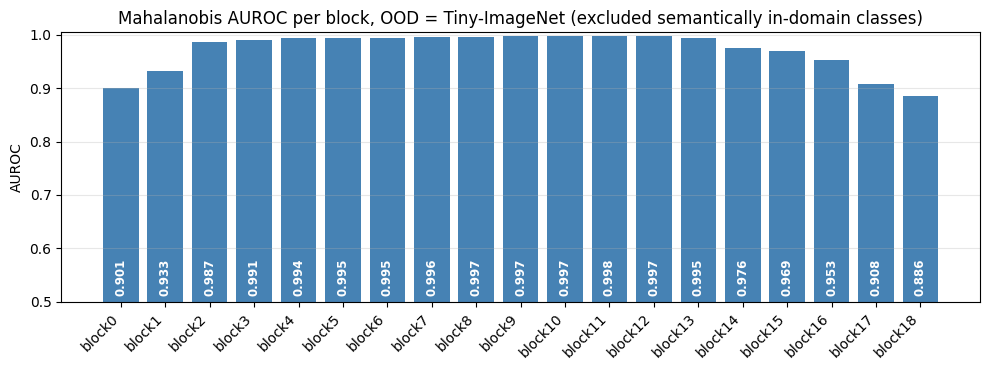

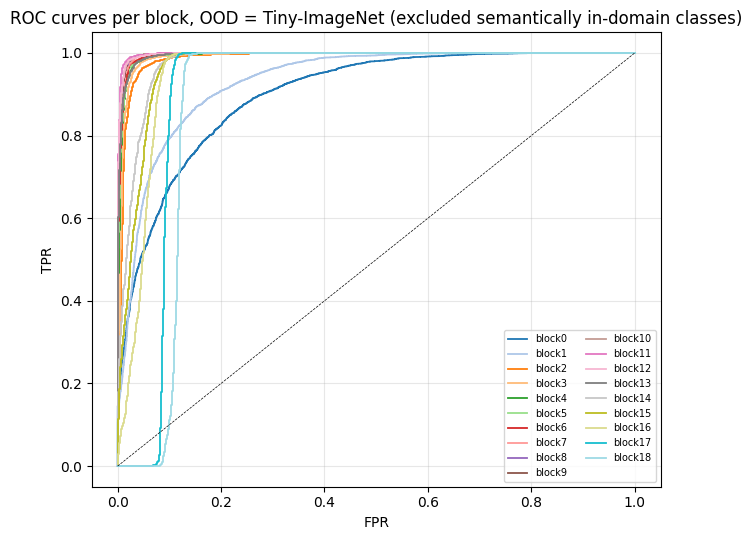

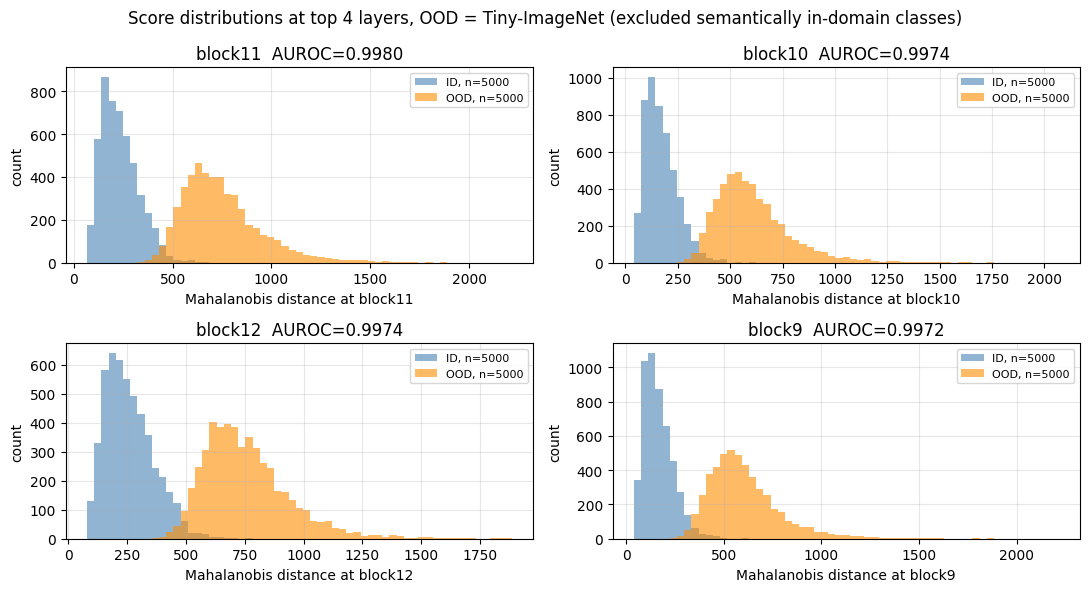

In [13]:
class TinyImageNetFlat(Dataset):
    """Flat reader for Tiny-ImageNet's `train/<wnid>/images/*.JPEG` layout."""
    def __init__(self, root, transform, exclude_wnids=None):
        paths = []
        exclude_wnids = set(exclude_wnids or [])
        for wnid in sorted(os.listdir(root)):
            if wnid in exclude_wnids:
                continue
            d = os.path.join(root, wnid, "images")
            if not os.path.isdir(d): continue
            for f in sorted(os.listdir(d)):
                if f.lower().endswith(".jpeg"):
                    paths.append(os.path.join(d, f))
        self.paths = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.transform(Image.open(self.paths[i]).convert("RGB")), 0


def download_tiny_imagenet():
    target = os.path.join(DATA_DIR, "tiny-imagenet-200")
    if os.path.isdir(target):
        return target
    zip_path = os.path.join(DATA_DIR, "tiny-imagenet-200.zip")
    if not os.path.exists(zip_path):
        url = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
        print(f"downloading {url} ...")
        urllib.request.urlretrieve(url, zip_path)
    print("unzipping ...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_DIR)
    return target


# Exclude semantically in-domain Tiny-ImageNet classes (dog/cat breeds)
# from OOD evaluation. Data remains on disk and can be reused later.
EXCLUDED_TINY_WNIDS = {
    "n02106662",  # German shepherd
    "n02123045",  # tabby
    "n02124075",  # Egyptian cat
    "n02099601",  # golden retriever
    "n02085620",  # Chihuahua
    "n02113799",  # standard poodle
    "n02099712",  # Labrador retriever
    "n02094433",  # Yorkshire terrier
}

tin_train_root = os.path.join(download_tiny_imagenet(), "train")
tin_base_all = TinyImageNetFlat(tin_train_root, transform=eval_tf)
tin_base = TinyImageNetFlat(tin_train_root, transform=eval_tf, exclude_wnids=EXCLUDED_TINY_WNIDS)

excluded_count = len(tin_base_all) - len(tin_base)
print(f"Tiny-ImageNet raw images: {len(tin_base_all)}")
print(f"Excluded wnids: {sorted(EXCLUDED_TINY_WNIDS)}")
print(f"Excluded images: {excluded_count}")

tin_ds = OODWrapper(tin_base, n=N_OOD_TEST, seed=0)
print(f"Tiny-ImageNet used for OOD: {len(tin_ds)} images")

tin_result = analyze_ood_source(tin_ds, "tiny_imagenet", "Tiny-ImageNet (excluded semantically in-domain classes)")

### Inspection OOD classes considered In-domain

In [14]:
from collections import Counter
from IPython.display import display

# Load Tiny-ImageNet class descriptions to interpret which classes are most affected by false in-domain predictions.
tiny_root = os.path.join(DATA_DIR, "tiny-imagenet-200")
wnids_path = os.path.join(tiny_root, "wnids.txt")
words_path = os.path.join(tiny_root, "words.txt")


def load_tiny_imagenet_descriptions(wnids_file, words_file):
    wnids = [line.strip() for line in open(wnids_file, encoding="utf-8") if line.strip()]
    descriptions = {}
    with open(words_file, encoding="utf-8") as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            if "\t" in line:
                wnid, description = line.split("\t", 1)
            else:
                parts = line.split(None, 1)
                wnid = parts[0]
                description = parts[1] if len(parts) > 1 else ""
            descriptions[wnid] = description
    return wnids, descriptions

wnids, wnid_descriptions = load_tiny_imagenet_descriptions(wnids_path, words_path)
wnid_table = pd.DataFrame(
    {
        "wnid": wnids,
        "description": [wnid_descriptions.get(wnid, "") for wnid in wnids],
    }
)

# Identify the best-performing layer and analyze which Tiny-ImageNet classes contribute most to false in-domain predictions at that layer.
best_layer = max(LAYER_NAMES, key=lambda name: tin_result["per_layer"][name]["auroc"])
id_threshold = np.quantile(md_id_test[best_layer], 0.95) # ID threshold at 95th percentile for the best layer
ood_scores = tin_result["md_ood"][best_layer]
false_in_mask = ood_scores < id_threshold

sample_paths = [tin_ds.base.paths[int(i)] for i in tin_ds.idx]
sample_wnids = [os.path.basename(os.path.dirname(os.path.dirname(path))) for path in sample_paths]
failed_counts = Counter(wnid for wnid, is_false_in in zip(sample_wnids, false_in_mask) if is_false_in)

failed_df = pd.DataFrame(
    [
        (wnid, count, wnid_descriptions.get(wnid, ""))
        for wnid, count in failed_counts.items()
    ],
    columns=["wnid", "false_in_domain_count", "description"],
).sort_values(["false_in_domain_count", "wnid"], ascending=[False, True]).reset_index(drop=True)

print(f"Best AUROC layer: {best_layer}")
print(f"ID threshold (95th percentile): {id_threshold:.4f}")
print(f"False in-domain Tiny-ImageNet samples: {int(false_in_mask.sum())} / {len(false_in_mask)}")
print(f"Distinct Tiny-ImageNet classes with false in-domain samples: {len(failed_df)}")
display(failed_df)

combined_txt_path = os.path.join(CACHE_DIR, "tiny_imagenet_wnids_with_descriptions.txt")
with open(combined_txt_path, "w", encoding="utf-8") as handle:
    for wnid in wnids:
        handle.write(f"{wnid}\t{wnid_descriptions.get(wnid, '')}\n")
print(f"Saved combined wnid-description list to {combined_txt_path}")

Best AUROC layer: block11
ID threshold (95th percentile): 406.4401
False in-domain Tiny-ImageNet samples: 21 / 5000
Distinct Tiny-ImageNet classes with false in-domain samples: 21


,wnid,false_in_domain_count,description
0,n01768244,1,trilobite
1,n01950731,1,"sea slug, nudibranch"
2,n02125311,1,"cougar, puma, catamount, mountain lion, painte..."
3,n02206856,1,bee
4,n02814533,1,"beach wagon, station wagon, wagon, estate car,..."
5,n02823428,1,beer bottle
6,n02950826,1,cannon
7,n02963159,1,cardigan
8,n03089624,1,"confectionery, confectionary, candy store"
9,n03100240,1,convertible


Saved combined wnid-description list to cache\tiny_imagenet_wnids_with_descriptions.txt


  load  ood_test_tiny_imagenet.npz
Using layer: block11
Most ID-like OOD samples (top-6)


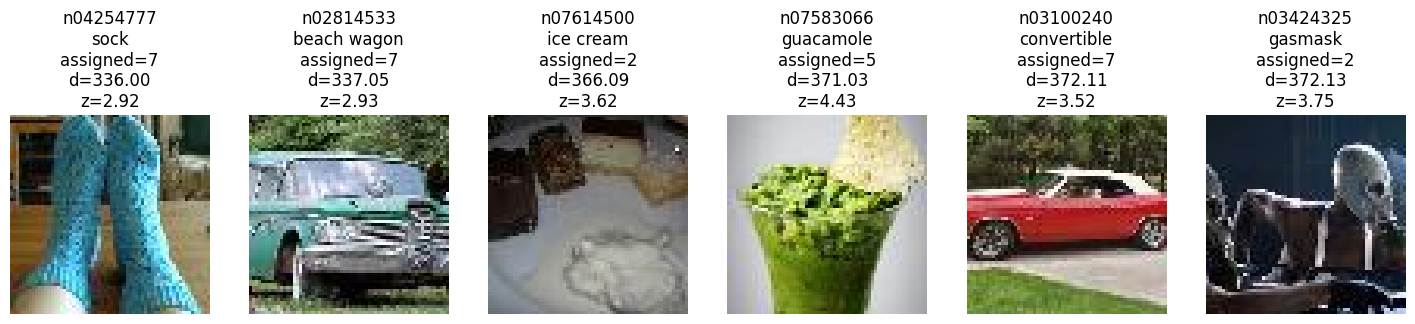

Most outlying assigned OOD samples (top-6)


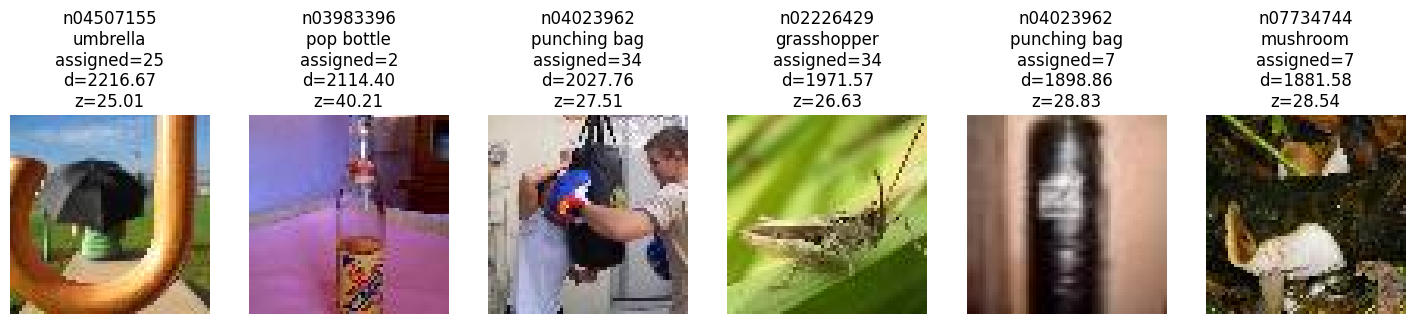

Highest z-score OOD samples (top-6)


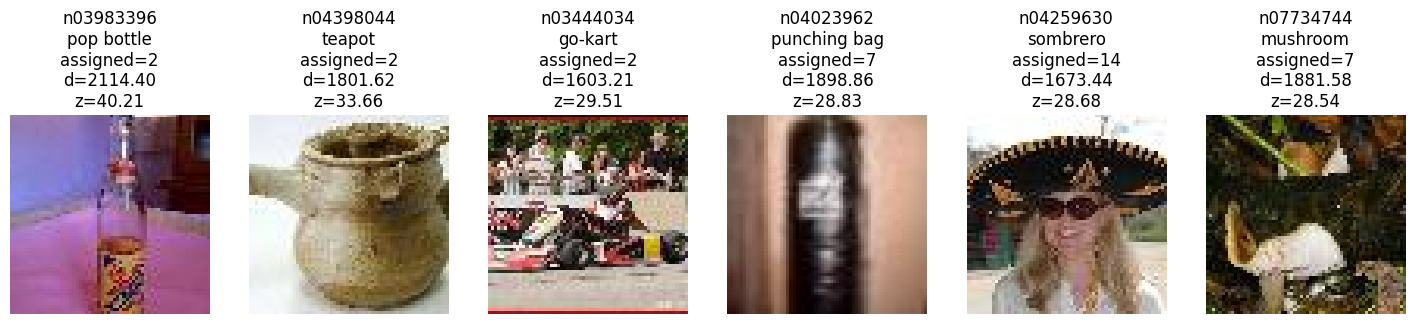

Saved per-sample report to cache\tiny_imagenet_ood_per_sample_block11.csv


In [15]:
# Per-sample OOD diagnostics: nearest-class, distances, and z-scores
# Produces three top-10 tables: (A) smallest distance (most ID-like),
# (B) largest distance among those still assigned to a class (extreme outliers),
# (C) highest z-score relative to that class' ID-distance distribution.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

layer = best_layer
means, prec = gaussians[layer]

# Re-load OOD features (cached) to get per-sample features at the chosen layer
ood_out = extract_cached(f"ood_test_tiny_imagenet", tin_ds, also_logits=False)
ood_feats = ood_out["features"][layer].astype(np.float64)

# ID (fit) features at same layer and labels
id_feats = fit_out["features"][layer].astype(np.float64)
id_labels = fit_labels

# Vectorized Mahalanobis distances to all class means
P = prec.astype(np.float64)
Px = ood_feats @ P                           # (N, D)
quad_x = np.einsum("nd,nd->n", Px, ood_feats)  # (N,)
Pmu = means @ P                              # (C, D)
quad_mu = np.einsum("cd,cd->c", Pmu, means) # (C,)
cross = Px @ means.T                         # (N, C)
all_dists = quad_x[:, None] + quad_mu[None, :] - 2.0 * cross  # (N, C)

# nearest class and min distance
nearest = all_dists.argmin(axis=1)
min_dist = all_dists.min(axis=1)

# Compute per-class ID distance distributions (to their own class mean)
# Use ID-fit features and same Mahalanobis computation
Px_id = id_feats @ P
quad_x_id = np.einsum("nd,nd->n", Px_id, id_feats)
cross_id = Px_id @ means.T
all_dists_id = quad_x_id[:, None] + quad_mu[None, :] - 2.0 * cross_id  # (N_id, C)
# For class c, distances to its mean are all_dists_id[labels==c, c]

class_stats = {}
for c in range(means.shape[0]):
    sel = (id_labels == c)
    if sel.sum() == 0:
        class_stats[c] = (0.0, 1.0)
        continue
    dists_c = all_dists_id[sel, c]
    class_stats[c] = (float(dists_c.mean()), float(dists_c.std()) if dists_c.std() > 0 else 1e-6)

# Build DataFrame of OOD samples
sample_paths = [tin_ds.base.paths[int(i)] for i in tin_ds.idx]
sample_wnids = [os.path.basename(os.path.dirname(os.path.dirname(p))) for p in sample_paths]

rows = []
for i, path in enumerate(sample_paths):
    c = int(nearest[i])
    d = float(min_dist[i])
    mu, sigma = class_stats.get(c, (0.0, 1.0))
    z = (d - mu) / (sigma + 1e-12)
    rows.append({
        "idx": i,
        "path": path,
        "wnid": sample_wnids[i],
        "assigned_class": c,
        "distance": d,
        "z_score": z,
        "description": wnid_descriptions.get(sample_wnids[i], ""),
    })

df = pd.DataFrame(rows)

# Helper to find a representative ID sample (closest to class mean)
rep_id_map = {}
for c in range(means.shape[0]):
    sel_idx = np.where(id_labels == c)[0]
    if len(sel_idx) == 0:
        rep_id_map[c] = None
        continue
    d_to_mean = all_dists_id[sel_idx, c]
    best_local = sel_idx[int(np.argmin(d_to_mean))]
    # Map local fit index back to original dataset index via oxford_fit_ds.indices if available
    try:
        orig_idx = oxford_fit_ds.indices[best_local]
        rep_img, _ = oxford_train_eval[orig_idx]
        rep_id_map[c] = (orig_idx, rep_img)
    except Exception:
        rep_id_map[c] = None

# Top-10 tables
print(f"Using layer: {layer}")

'''
print("\nTop-10 OOD samples most ID-like (smallest Mahalanobis distance)")
display(df.sort_values("distance").head(10))

print("\nTop-10 OOD samples most outlying among assigned-class (largest min-distance)")
display(df.sort_values("distance", ascending=False).head(10))

print("\nTop-10 by z-score (distance relative to assigned-class distribution)")
display(df.sort_values("z_score", ascending=False).head(10))
'''

# Display images for the three lists (compact)

def truncate_desc(desc):
    if not desc:
        return ""
    # take text before first comma and strip
    return desc.split(",", 1)[0].strip()

def show_samples(subdf, title):
    print(title)
    n = min(6, len(subdf))
    fig, axs = plt.subplots(1, n, figsize=(3*n, 3))
    for ax, (_, r) in zip(axs, subdf.iterrows()):
        img = Image.open(r.path).convert("RGB")
        ax.imshow(img)
        # Plot the truncated OOD class description in the title
        desc_short = truncate_desc(r.description or "")
        ax.set_title(f"{r.wnid}\n{desc_short}\nassigned={r.assigned_class}\nd={r.distance:.2f}\nz={r.z_score:.2f}")
        ax.axis('off')
    plt.show()

show_samples(df.sort_values("distance").head(6), "Most ID-like OOD samples (top-6)")
show_samples(df.sort_values("distance", ascending=False).head(6), "Most outlying assigned OOD samples (top-6)")
show_samples(df.sort_values("z_score", ascending=False).head(6), "Highest z-score OOD samples (top-6)")

# Optionally: save detailed CSV for offline inspection
out_csv = os.path.join(CACHE_DIR, f"tiny_imagenet_ood_per_sample_{layer}.csv")
df.to_csv(out_csv, index=False)
print(f"Saved per-sample report to {out_csv}")
